In [12]:
import random

In [13]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model,
    convert_model,
    create_api,
    create_docker
)
from pycaret.utils import version

In [14]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]

In [15]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("../wine_spectator.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [16]:

unnamed_cols=df.filter(regex="Unnamed")
df = df.drop(categorical_cols, axis=1)
df = df.drop(extra_cols, axis=1)
df = df.drop(unnamed_cols, axis=1)
df = df.drop(predictors, axis=1)

df = df[id_cols+other_ratings+target_cols]
indices = list(df.index)
n_samples = len(indices)
train_samples = int(0.8 * n_samples)
test_samples = n_samples - train_samples
print(f"train_samples = {train_samples}")
print(f"test_samples = {test_samples}")
random.shuffle(indices)
pick_k_random_indices = random.sample(indices, train_samples)
not_picked_indices = set(indices).difference(pick_k_random_indices)
df_train = df.loc[pick_k_random_indices, :]
df_train_id = df_train[id_cols]
df_train = df_train.drop(id_cols, axis=1)
df_train = df_train.dropna(subset=target_cols, axis=0)

train_samples = 1680
test_samples = 420


In [17]:
df_test = df.loc[not_picked_indices, :]
df_test_id = df_test[id_cols]
df_test_truth = df_test[target_cols]
df_test = df_test.drop(id_cols, axis=1)
df_test = df_test.drop(target_cols, axis=1)

In [18]:
print(list(df.describe()))

['productID', 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP', 'WS']


In [29]:
print("2. Initialize Setup")
reg1 = setup(
    data=df_train,
    target="WS",
    experiment_name='ws_from_other',
    imputation_type='iterative',    
)

2. Initialize Setup


,Description,Value
0,Session id,6362
1,Target,WS
2,Target type,Regression
3,Original data shape,"(1665, 13)"
4,Transformed data shape,"(1665, 13)"
5,Transformed train set shape,"(1165, 13)"
6,Transformed test set shape,"(500, 13)"
7,Numeric features,12
8,Rows with missing values,100.0%
9,Preprocess,True


In [ ]:
print("3. Compare Baseline")

best_model = compare_models(fold=5)

In [ ]:
print("4. Create Model")
lr = create_model('lr')
lr = tune_model(lr, n_iter=5, optimize='RMSE')
evaluate_model(lr)

In [ ]:
rf = create_model('rf')
rf = tune_model(rf, n_iter=5, optimize='RMSE')
evaluate_model(rf)

In [ ]:
knn=create_model('knn')
knn = tune_model(knn, n_iter=5, optimize='RMSE')
evaluate_model(knn)

In [ ]:
print("5. Tune Hyperparameters")
lightgbm = create_model('lightgbm')
lightgbm = tune_model(lightgbm, n_iter=5, optimize='MAE')
evaluate_model(lightgbm)

In [ ]:
print("6. Ensemble Model")

In [ ]:
dt = create_model('dt')

In [ ]:
bagged_dt = ensemble_model(dt, n_estimators=50)

In [ ]:
boosted_dt = ensemble_model(dt, method='Boosting')

In [ ]:
print("7. Blend Models")

In [ ]:
list(models().index)

In [ ]:
top_five = compare_models(n_select=5, fold=5, include=list(models().index.difference(['gbr'])))

In [ ]:
blender = blend_models(estimator_list=top_five)

In [ ]:
print("8. Stack Models")

In [ ]:
stacker = stack_models(estimator_list=top_five)

In [ ]:
print("9. Analyze Model")

In [ ]:
plot_model(stacker)

In [ ]:
plot_model(stacker, plot='error')

In [ ]:
evaluate_model(stacker)

In [ ]:
print("10. Interpret Model")

In [ ]:
#interpret_model(stacker)

In [ ]:
interpret_model(stacker, plot='correlation')

In [ ]:
#interpret_model(stacker, plot='reason', observation=12)

In [ ]:
print("11. AutoML()")

In [ ]:
best = automl(optimize='RMSE')
print(best)

In [ ]:
save_model(best, model_name='best-model-other')

In [19]:
loaded_bestmodel = load_model('best-model-other')
print(loaded_bestmodel)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('iterative_imputer',
                 TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=2584),
                                                                 cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=2584),
                                                                                                              {}),
                                                                 categorical_indices=[],
                                                                 max_iter=5,
                                                                 num_estimator=LGBMRegressor(random_state=2584),
                                                                 num_estimator...
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('trained_model',
                 Vo

In [20]:
print(loaded_bestmodel[0])

TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=2584),
                                                cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=2584),
                                                                                             {}),
                                                categorical_indices=[],
                                                max_iter=5,
                                                num_estimator=LGBMRegressor(random_state=2584),
                                                num_estimator_prepare_for_categoricals_type=(LGBMRegressor(random_state=2584),
                                                                                             {}),
                                                random_state=2584,
                                                skip_complete=True))


In [21]:
print("12. Predict Model")

12. Predict Model


In [23]:
predict_new = predict_model(loaded_bestmodel, data=df_test)
predict_new.head()

,JS,WW,D,BH,W&S,WE,RP,JD,SJ,V,CG,TP,prediction_label
2,95.0,NaN,NaN,NaN,NaN,90.0,94.0,NaN,NaN,NaN,NaN,NaN,92.695549
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.469928
6,93.0,96.0,91.0,NaN,NaN,92.0,91.0,94.0,NaN,NaN,NaN,NaN,92.008718
12,92.0,92.0,NaN,NaN,NaN,NaN,NaN,90.0,NaN,NaN,91.0,NaN,90.952171
17,NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.850880


Text(0, 0.5, 'actual WS rating')

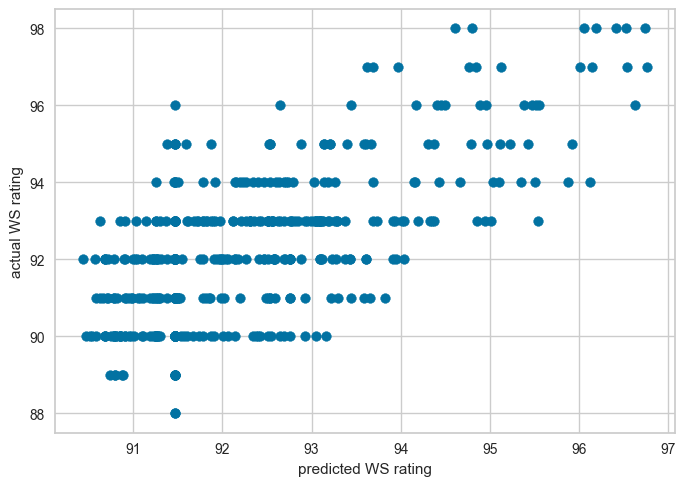

In [24]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(predict_new['prediction_label'],df_test_truth)
ax.set_xlabel('predicted WS rating')
ax.set_ylabel('actual WS rating')

In [25]:
#convert_model(best_model,'c')

In [30]:
create_api(loaded_bestmodel,api_name='predict_ws_from_other')

API successfully created. This function only creates a POST API, it doesn't run it automatically. To run your API, please run this command --> !python predict_ws_from_other.py


In [31]:
create_docker(api_name='predict_ws_from_other')

Writing requirements.txt
Writing Dockerfile
Dockerfile and requirements.txt successfully created.
    To build image you have to run --> !docker image build -f "Dockerfile" -t IMAGE_NAME:IMAGE_TAG .
            
